# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [92]:
import re
import time
import math
import random
import unicodedata
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [93]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký m...,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách ...,negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạn...",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi ...",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bả...",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Dataset cua nhom tim


In [94]:
train_df = pd.read_csv("synthetic_train.csv")
validate_df = pd.read_csv("synthetic_val.csv")

print("Train shape:", train_df.shape)
print("Validate shape:", validate_df.shape)
print("\nTrain:")
print(len(train_df), "Rows")
display(train_df.head())
print("\nValidate:")
print(len(validate_df), "Rows")
display(validate_df.head())

print("\nTrain Sentiment distribution:")
print(train_df["sentiment"].value_counts())
print("\nTrain Topic distribution:")
print(train_df["topic"].value_counts())
print("\nValidate Sentiment distribution:")
print(validate_df["sentiment"].value_counts())
print("\nValidate Topic distribution:")
print(validate_df["topic"].value_counts())


Train shape: (7829, 3)
Validate shape: (1951, 3)

Train:
7829 Rows


,sentence,sentiment,topic
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility
1,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,curriculum
2,Chương trình học giúp tôi trở thành một chuyên...,positive,curriculum
3,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,curriculum
4,Chị ấy luôn tỉ mỉ trong công việc.,neutral,others



Validate:
1951 Rows


,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,facility
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,curriculum
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,others



Train Sentiment distribution:
sentiment
negative    2711
positive    2709
neutral     2409
Name: count, dtype: int64

Train Topic distribution:
topic
others        2059
lecturer      2026
curriculum    1925
facility      1819
Name: count, dtype: int64

Validate Sentiment distribution:
sentiment
negative    686
positive    680
neutral     585
Name: count, dtype: int64

Validate Topic distribution:
topic
lecturer      515
others        488
facility      476
curriculum    472
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

In [95]:
# TODO 1: tạo cột binary_sentiment
df["binary_sentiment"] = df["sentiment"].apply(
    lambda x: "positive" if x == "positive" else "non_positive"
)
df["binary_sentiment_num"] = df["binary_sentiment"].apply(
    lambda x: 1 if x == "positive" else 0
)
print("RESULT task 1.1")
print(df[["sentiment", "binary_sentiment"]].head(10))
print(df[["sentiment", "binary_sentiment_num"]].head(10))

display(df[["text", "sentiment", "binary_sentiment"]].head())

# TODO 2:
# - tạo ví dụ multilabel
multilabel = "Gia sư của tôi dạy rất dễ hiểu nhưng phòng học hơi nóng vì máy lạnh không hoạt động tốt"
labels = ["teaching", "facility"]

print("Multilabel example:")
print("Text:", multilabel)
print("Labels:", labels)
# - đề xuất cấu trúc hierarchical label
hierarchical_label = {
    "academic" : [
        "teaching",
        "curriculum"
    ],
    "service" : [
        "administration",
        "facility"
    ]
}

print("\nHierarchical Label")
print(hierarchical_label)

print("\nSo sánh text classification vs sequence labeling.")
print(\
"Classification → 1 câu → 1 nhãn (label) " \
"\nSequence Labeling → 1 câu → nhiều từ/token → mỗi từ được gán 1 nhãn")

RESULT task 1.1
  sentiment binary_sentiment
0  negative     non_positive
1  negative     non_positive
2  positive         positive
3  negative     non_positive
4  positive         positive
5  negative     non_positive
6  negative     non_positive
7  positive         positive
8  negative     non_positive
9   neutral     non_positive
  sentiment  binary_sentiment_num
0  negative                     0
1  negative                     0
2  positive                     1
3  negative                     0
4  positive                     1
5  negative                     0
6  negative                     0
7  positive                     1
8  negative                     0
9   neutral                     0


,text,sentiment,binary_sentiment
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,positive
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,non_positive
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,positive


Multilabel example:
Text: Gia sư của tôi dạy rất dễ hiểu nhưng phòng học hơi nóng vì máy lạnh không hoạt động tốt
Labels: ['teaching', 'facility']

Hierarchical Label
{'academic': ['teaching', 'curriculum'], 'service': ['administration', 'facility']}

So sánh text classification vs sequence labeling.
Classification → 1 câu → 1 nhãn (label) 
Sequence Labeling → 1 câu → nhiều từ/token → mỗi từ được gán 1 nhãn


# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [96]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text"].map(normalize_text)
# normlize len dataset cua nhom
train_df['text_norm']=train_df["sentence"].map(normalize_text)
display(df[["text", "text_norm"]].head())
display(train_df[["sentence", "text_norm"]].head())

,text,text_norm
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...","trong học kỳ này, bài giảng rõ ràng, ví dụ thự..."
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,cá nhân mình thấy nhà vệ sinh chưa sạch và thi...
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,cá nhân mình thấy hệ thống học trực tuyến chạy...


,sentence,text_norm
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,đội ngũ bảo trì quá thưa thớt dẫn đến không đả...
1,Phương pháp giảng dạy phù hợp với các đối tượn...,phương pháp giảng dạy phù hợp với các đối tượn...
2,Chương trình học giúp tôi trở thành một chuyên...,chương trình học giúp tôi trở thành một chuyên...
3,Tôi nghĩ rằng chương trình đào tạo có thể có t...,tôi nghĩ rằng chương trình đào tạo có thể có t...
4,Chị ấy luôn tỉ mỉ trong công việc.,chị ấy luôn tỉ mỉ trong công việc.


## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [97]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được",
    "đz": "đẹp trai",
    "qs": "quá"
}

text1 = "Khóa học này tuyệt vời!!!"
text_keep_punct = text1
text_remove_punct = text1.translate(
    str.maketrans("", "", string.punctuation)
)
print("1. So sánh dấu câu")
#in nhầm text keep punct thành text
print("\nkeep punct: ", text_keep_punct)
print("remove punct: ", text_remove_punct)

text2 = "Khóa học này tuyệt vời 😍"
text_keep_emoji = text2
text_remove_emoji = re.sub(
    r'[\U0001F300-\U0001FAFF]',
    '',
    text2
)
print("\n2. So sánh emoji")
print("keep emoji: ", text_keep_emoji)
print("remove emoji: ", text_remove_emoji)

test_teencode = "Đăng Ninh qs đz"

def normalize_teencode(text):
    toks = normalize_text(text).split()
    toks = [TEENCODE_MAP.get(t, t) for t in toks]
    return " ".join(toks)

# TODO: mở rộng bảng từ viết tắt và kiểm thử trên dữ liệu thật
print("\n3. Chuẩn hóa teencode")
print("trước khi chuẩn hóa: ", test_teencode)
print("sau khi chuẩn hóa: ", normalize_teencode(test_teencode))

def preprocess_text(text):
    # Xóa emoji
    text = re.sub(
        r'[\U0001F300-\U0001FAFF]',
        '',
        text
    )

    # Xóa dấu câu
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    return text
text = "Đăng Ninh qs đz!!!! 😍"

print("\n4. Phân tích trường hợp preprocessing làm mất tín hiệu sentiment.")
print("Trước:", text)
print("Sau:", normalize_teencode(preprocess_text(text)))
print("Preprocessing giúp làm sạch dữ liệu nhưng có thể làm mất tín hiệu sentiment.\nViệc loại bỏ dấu câu như '!!!' có thể làm mất thông tin về mức độ cảm xúc.\nViệc loại bỏ emoji như 😍 cũng có thể làm mất tín hiệu cảm xúc tích cực.\nVì vậy cần lựa chọn preprocessing phù hợp cho bài toán sentiment analysis.")

1. So sánh dấu câu

keep punct:  Khóa học này tuyệt vời!!!
remove punct:  Khóa học này tuyệt vời

2. So sánh emoji
keep emoji:  Khóa học này tuyệt vời 😍
remove emoji:  Khóa học này tuyệt vời 

3. Chuẩn hóa teencode
trước khi chuẩn hóa:  Đăng Ninh qs đz
sau khi chuẩn hóa:  đăng ninh quá đẹp trai

4. Phân tích trường hợp preprocessing làm mất tín hiệu sentiment.
Trước: Đăng Ninh qs đz!!!! 😍
Sau: đăng ninh quá đẹp trai
Preprocessing giúp làm sạch dữ liệu nhưng có thể làm mất tín hiệu sentiment.
Việc loại bỏ dấu câu như '!!!' có thể làm mất thông tin về mức độ cảm xúc.
Việc loại bỏ emoji như 😍 cũng có thể làm mất tín hiệu cảm xúc tích cực.
Vì vậy cần lựa chọn preprocessing phù hợp cho bài toán sentiment analysis.


# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train: 90
Test : 30

Train label distribution:
sentiment
positive    0.333333
negative    0.333333
neutral     0.333333
Name: proportion, dtype: float64


## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [99]:
#task 3.1
validate_df, test_df = train_test_split(
    validate_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validate_df["sentiment"]
)

print("Train:", len(train_df))
print("Validation:", len(validate_df))
print("Test:", len(test_df))

print("\nTrain sentiment:")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nValidation sentiment:")
print(validate_df["sentiment"].value_counts(normalize=True))

print("\nTest sentiment:")
print(test_df["sentiment"].value_counts(normalize=True))

#chua giai thich
#task 3.2
# Chia dữ liêu
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

# TF-IDF học từ Train
tfidf = TfidfVectorizer()
tfidf.fit(X_train)

# Biến đổi Train và Test
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#task 3.3
X_train = train_df["sentence"]
y_train = train_df["sentiment"]

X_validate = validate_df["sentence"]
y_validate = validate_df["sentiment"]

X_test = test_df["sentence"]
y_test = test_df["sentiment"]

# TODO: viết hàm kiểm tra duplicate giữa train và test
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]

print("\nkết quả task 3.3")
print("Exact overlap:", len(find_overlap(X_train, X_test))) 

#task 3.4
print("\nTask 3.4:")
print("Dataset hiện tại không có cột thời gian.")
print("Vì vậy sử dụng random split thay vì temporal split.")

Train: 7829
Validation: 975
Test: 976

Train sentiment:
sentiment
negative    0.346277
positive    0.346021
neutral     0.307702
Name: proportion, dtype: float64

Validation sentiment:
sentiment
negative    0.351795
positive    0.348718
neutral     0.299487
Name: proportion, dtype: float64

Test sentiment:
sentiment
negative    0.351434
positive    0.348361
neutral     0.300205
Name: proportion, dtype: float64

kết quả task 3.3
Exact overlap: 0

Task 3.4:
Dataset hiện tại không có cột thời gian.
Vì vậy sử dụng random split thay vì temporal split.


# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [100]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=feature_names
)
display(sample.iloc[:, :20])

Binary shape: (7829, 1820)
BoW shape   : (7829, 1820)


,24,active,ae,ai,all,am,an,anh,are,atm,ba,bai,ban,bao,bay,bbq,bida,bikemot,biên,biến
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

In [101]:
#task 4.1
texts = [
    "khóa học này rất hay",
    "khóa học này rất rất hay",
    "khóa học không hay"
]

# Count BoW
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(texts)

# Binary BoW
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(texts)

print("Vocabulary:")
print(count_vectorizer.get_feature_names_out())

print("\nCount BoW:")
print(X_count.toarray())

print("\nBinary BoW:")
print(X_binary.toarray())

#Task 4.2
settings = [
    ("default", None, None),
    ("min_df=2", 2, None),
    ("max_df=0.5", None, 0.5),
    ("min_df=2, max_df=0.8", 2, 0.8)
]

print("\ntask 4.2")
for name, min_df, max_df in settings:
    vectorizer = CountVectorizer(
        min_df=min_df if min_df is not None else 1,
        max_df=max_df if max_df is not None else 1.0
    )
    
    X = vectorizer.fit_transform(texts)

    print(name)
    print("Vocabulary:", vectorizer.get_feature_names_out())
    print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
    print()

# Task 4.3
stopwords_custom = ["này", "rất", "không"]

vectorizer_stopwords = CountVectorizer(
    stop_words=stopwords_custom
)

X_stopwords = vectorizer_stopwords.fit_transform(texts)

print("\ntask 4.3")
print("Vocabulary sau khi bỏ stopwords:")
print(vectorizer_stopwords.get_feature_names_out())

print("Vocabulary size:",
      len(vectorizer_stopwords.get_feature_names_out()))

print("BoW:")
print(X_stopwords.toarray())

#Task 4.4

#Tạo BoW
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(texts)

#Vocabulary size
vocab_size = len(vectorizer.get_feature_names_out())

#Sparsity
sparsity = 1 - (X_bow.nnz / X_bow.shape[0] / X_bow.shape[1])

#Memory
memory_bytes = X_bow.data.nbytes + X_bow.indices.nbytes + X_bow.indptr.nbytes

print("\ntask 4.4")
print("Vocabulary size:", vocab_size)
print("Sparsity:", sparsity)
print("Memory:", memory_bytes, "bytes")
print("Memory:", memory_bytes / 1024, "KB")

def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

print("BoW sparsity:", round(sparsity(X_bow), 4))

# TODO: thử min_df=2, max_df=0.9 và so sánh kích thước vocabulary

Vocabulary:
['hay' 'học' 'khóa' 'không' 'này' 'rất']

Count BoW:
[[1 1 1 0 1 1]
 [1 1 1 0 1 2]
 [1 1 1 1 0 0]]

Binary BoW:
[[1 1 1 0 1 1]
 [1 1 1 0 1 1]
 [1 1 1 1 0 0]]

task 4.2
default
Vocabulary: ['hay' 'học' 'khóa' 'không' 'này' 'rất']
Vocabulary size: 6

min_df=2
Vocabulary: ['hay' 'học' 'khóa' 'này' 'rất']
Vocabulary size: 5

max_df=0.5
Vocabulary: ['không']
Vocabulary size: 1

min_df=2, max_df=0.8
Vocabulary: ['này' 'rất']
Vocabulary size: 2


task 4.3
Vocabulary sau khi bỏ stopwords:
['hay' 'học' 'khóa']
Vocabulary size: 3
BoW:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

task 4.4
Vocabulary size: 6
Sparsity: 0.2222222222222222
Memory: 184 bytes
Memory: 0.1796875 KB
BoW sparsity: 0.2222


# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [102]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

Shape: (7829, 1820)
Text: Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.
Top TF-IDF terms:
bảo                  0.372
thớt                 0.372
thưa                 0.355
sửa                  0.294
chữa                 0.291
ngũ                  0.249
trì                  0.220
đội                  0.214
dẫn                  0.210
đảm                  0.205


## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

In [103]:
# TODO: tạo ít nhất 3 cấu hình TF-IDF và lưu kết quả vào bảng
# Task 5.1
print("task 5.1")
print("Vocabulary:")
print(tfidf.get_feature_names_out())

print("\nTF-IDF:")
print(X_tfidf.toarray())

#Task 5.2
# TF-IDF với L1
tfidf_l1 = TfidfVectorizer(norm='l1')
X_l1 = tfidf_l1.fit_transform(texts)

#TF-IDF với L2
tfidf_l2 = TfidfVectorizer(norm='l2')
X_l2 = tfidf_l2.fit_transform(texts)

print("\nTask 5.2")
print("\nTF-IDF với norm='l1':")
print(X_l1.toarray())

print("\nTF-IDF với norm='l2':")
print(X_l2.toarray())

#Task 5.3
#Unigram
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1)
)

X_uni = tfidf_uni.fit_transform(texts)

#Unigram + Bigram
tfidf_ngram = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_ngram = tfidf_ngram.fit_transform(texts)

print("\nTask 5.3")
print("\nUnigram:")
print("Vocabulary:", tfidf_uni.get_feature_names_out())
print("Vocabulary size:", len(tfidf_uni.get_feature_names_out()))
print("Shape:", X_uni.shape)

print("\n(1,2) word n-gram:")
print("Vocabulary:", tfidf_ngram.get_feature_names_out())
print("Vocabulary size:", len(tfidf_ngram.get_feature_names_out()))
print("Shape:", X_ngram.shape)

# Task 5.4
#Lấy vocabulary
features = tfidf.get_feature_names_out()

#Lấy IDF
idf_values = tfidf.idf_

#Sắp xếp IDF từ cao xuống thấp
top_indices = np.argsort(idf_values)[::-1][:20]

print("\ntask 5.4")
print("Top 20 features có IDF cao nhất:")

for i in top_indices:
    print(features[i], "->", round(idf_values[i], 3))

task 5.1
Vocabulary:
['24' 'active' 'ae' ... 'ức' 'ứng' 'ửng']

TF-IDF:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.23915143 0.        ]]

Task 5.2

TF-IDF với norm='l1':
[[0.17936048 0.17936048 0.17936048 0.         0.23095928 0.23095928]
 [0.14570789 0.14570789 0.14570789 0.         0.18762544 0.37525088]
 [0.21307663 0.21307663 0.21307663 0.3607701  0.         0.        ]]

TF-IDF với norm='l2':
[[0.3978967  0.3978967  0.3978967  0.         0.51236445 0.51236445]
 [0.29760553 0.29760553 0.29760553 0.         0.38322131 0.76644261]
 [0.41285857 0.41285857 0.41285857 0.69903033 0.         0.        ]]

Task 5.3

U

# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [104]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word n-gram features: 21395
Char n-gram features: 12890


## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [108]:
# TODO: thực hiện benchmark word/char n-gram
#Task 6.1
#Word unigram
word_uni = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 1)
)

X_train_uni = word_uni.fit_transform(X_train)
X_test_uni = word_uni.transform(X_test)

model_uni = LogisticRegression(max_iter=1000)
model_uni.fit(X_train_uni, y_train)

pred_uni = model_uni.predict(X_test_uni)
acc_uni = accuracy_score(y_test, pred_uni)


#Word 1-2 gram
word_ngram = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2)
)

X_train_ngram = word_ngram.fit_transform(X_train)
X_test_ngram = word_ngram.transform(X_test)

model_ngram = LogisticRegression(max_iter=1000)
model_ngram.fit(X_train_ngram, y_train)

pred_ngram = model_ngram.predict(X_test_ngram)
acc_ngram = accuracy_score(y_test, pred_ngram)


#Character 3-5 gram
char_ngram = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_train_char = char_ngram.fit_transform(X_train)
X_test_char = char_ngram.transform(X_test)

model_char = LogisticRegression(max_iter=1000)
model_char.fit(X_train_char, y_train)

pred_char = model_char.predict(X_test_char)
acc_char = accuracy_score(y_test, pred_char)


#Kết quả
print("Task 6.1")
print("Word unigram accuracy:", acc_uni)
print("Word 1-2 gram accuracy:", acc_ngram)
print("Char 3-5 gram accuracy:", acc_char)

print("\nFeature count:")
print("Word unigram:", X_train_uni.shape[1])
print("Word 1-2 gram:", X_train_ngram.shape[1])
print("Char 3-5 gram:", X_train_char.shape[1])

# Task 6.2
typo_texts = [
    "Khóa học này rất hay",
    "Khóa học này rấ hay",
    "Khóa hoc này rất hay",
    "Khóa học không hay"
]

print("\nTask 6.2\n")

for text in typo_texts:
    X_uni = word_uni.transform([text])
    X_ngram = word_ngram.transform([text])
    X_char = char_ngram.transform([text])

    pred_uni = model_uni.predict(X_uni)[0]
    pred_ngram = model_ngram.predict(X_ngram)[0]
    pred_char = model_char.predict(X_char)[0]

    print("Text:", text)
    print("Word unigram:", pred_uni)
    print("Word 1-2 gram:", pred_ngram)
    print("Char 3-5 gram:", pred_char)
    print()

# Task 6.3
results = {
    "Word unigram": [acc_uni, X_train_uni.shape[1]],
    "Word 1-2 gram": [acc_ngram, X_train_ngram.shape[1]],
    "Char 3-5 gram": [acc_char, X_train_char.shape[1]]
}

print("Task 6.3\n")

for model_name, values in results.items():
    print(model_name)
    print("Accuracy:", values[0])
    print("Feature count:", values[1])
    print()

# Task 6.4
print("Task 6.4\n")

print("Word unigram:")
print("- Feature: ít nhất (1820)")
print("- Memory: thấp")
print("- Robustness với typo: thấp")

print("\nWord 1-2 gram:")
print("- Feature: nhiều hơn (21395)")
print("- Memory: cao hơn")
print("- Accuracy: tốt hơn word unigram")

print("\nChar 3-5 gram:")
print("- Feature: nhiều nhất (51921)")
print("- Memory: cao nhất")
print("- Robustness với typo: tốt hơn word n-gram trong nhiều trường hợp")

Task 6.1
Word unigram accuracy: 0.819672131147541
Word 1-2 gram accuracy: 0.8391393442622951
Char 3-5 gram accuracy: 0.8340163934426229

Feature count:
Word unigram: 1820
Word 1-2 gram: 21395
Char 3-5 gram: 51921

Task 6.2

Text: Khóa học này rất hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: positive

Text: Khóa học này rấ hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Text: Khóa hoc này rất hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Text: Khóa học không hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Task 6.3

Word unigram
Accuracy: 0.819672131147541
Feature count: 1820

Word 1-2 gram
Accuracy: 0.8391393442622951
Feature count: 21395

Char 3-5 gram
Accuracy: 0.8340163934426229
Feature count: 51921

Task 6.4

Word unigram:
- Feature: ít nhất (1820)
- Memory: thấp
- Robustness với typo: thấp

Word 1-2 gram:
- Feature: nhiều hơn (21395)
- Memory: cao hơn
- Accuracy: tốt hơn word 

# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [110]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

Hashing shape: (7829, 4096)


## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

In [111]:
# Task 7.1
bucket_sizes = [2**8, 2**10, 2**12, 2**16]

for n_features in bucket_sizes:
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False
    )

    X_hash = hash_vec.transform(X_train)

    print("n_features:", n_features)
    print("Shape:", X_hash.shape)
    print()

# Task 7.2
results = []

for n_features in bucket_sizes:
    # Hashing
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False
    )

    X_train_hash = hash_vec.transform(X_train)
    X_test_hash = hash_vec.transform(X_test)

    # Training time
    start_time = time.time()

    model_hash = LogisticRegression(max_iter=1000)
    model_hash.fit(X_train_hash, y_train)

    training_time = time.time() - start_time

    # Accuracy
    pred_hash = model_hash.predict(X_test_hash)
    accuracy = accuracy_score(y_test, pred_hash)

    # Memory tương đối
    memory = (
        X_train_hash.data.nbytes
        + X_train_hash.indices.nbytes
        + X_train_hash.indptr.nbytes
    )

    results.append([
        n_features,
        accuracy,
        training_time,
        memory / 1024
    ])

print("Task 7.2\n")
print("Bucket | Accuracy | Training time (s) | Memory (KB)")

for row in results:
    print(
        f"{row[0]:6d} | "
        f"{row[1]:.4f}| "
        f"{row[2]:.4f}| "
        f"{row[3]:.2f}"
    )

# Task 7.3
print("\nTask 7.3\n")

print("Feature collision xảy ra khi:Hai hoặc nhiều token khác nhau được HashingVectorizer ánh xạ vào cùng một bucket.")

print("\nẢnh hưởng:")
print("- Ít bucket -> collision nhiều hơn.")
print("- Nhiều bucket -> collision ít hơn.")
print("- Collision nhiều có thể làm giảm accuracy.")

print("\nTrong kết quả:")
print("256 bucket có accuracy thấp nhất:", 0.7593)
print("4096 bucket có accuracy cao nhất:", 0.8271)

print("\ntask7.4")
print("Feature Hashing phù hợp hơn TF-IDF vocabulary truyền thống khi dataset có kích thước rất lớn, " \
"vocabulary rất lớn hoặc dữ liệu liên tục thay đổi. Thì Hashing không cần lưu toàn bộ vocabulary nên giúp kiểm soát " \
"memory và giữ số lượng feature cố định. Tuy nhiên hashing có thể xảy ra feature collision và khó giải thích ý nghĩa của từng feature.")

n_features: 256
Shape: (7829, 256)

n_features: 1024
Shape: (7829, 1024)

n_features: 4096
Shape: (7829, 4096)

n_features: 65536
Shape: (7829, 65536)

Task 7.2

Bucket | Accuracy | Training time (s) | Memory (KB)
   256 | 0.7469| 0.0830| 1386.18
  1024 | 0.8023| 0.0957| 1409.92
  4096 | 0.8105| 0.1724| 1418.36
 65536 | 0.8105| 1.1425| 1419.47

Task 7.3

Feature collision xảy ra khi:Hai hoặc nhiều token khác nhau được HashingVectorizer ánh xạ vào cùng một bucket.

Ảnh hưởng:
- Ít bucket -> collision nhiều hơn.
- Nhiều bucket -> collision ít hơn.
- Collision nhiều có thể làm giảm accuracy.

Trong kết quả:
256 bucket có accuracy thấp nhất: 0.7593
4096 bucket có accuracy cao nhất: 0.8271

task7.4
Feature Hashing phù hợp hơn TF-IDF vocabulary truyền thống khi dataset có kích thước rất lớn, vocabulary rất lớn hoặc dữ liệu liên tục thay đổi. Thì Hashing không cần lưu toàn bộ vocabulary nên giúp kiểm soát memory và giữ số lượng feature cố định. Tuy nhiên hashing có thể xảy ra feature collisio

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [112]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji
0,59,13,0,1,0,0
1,59,13,0,1,0,0
2,62,15,0,0,0,0
3,55,13,0,1,0,0
4,70,17,0,0,0,0


## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [113]:
from scipy.sparse import csr_matrix, hstack
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from IPython.display import display

X_train = train_df["sentence"].reset_index(drop=True)
y_train = train_df["sentiment"].reset_index(drop=True)
X_validate = validate_df["sentence"].reset_index(drop=True)
y_validate = validate_df["sentiment"].reset_index(drop=True)
X_test = test_df["sentence"].reset_index(drop=True)
y_test = test_df["sentiment"].reset_index(drop=True)
for texts_part, labels_part in [(X_train,y_train),(X_validate,y_validate),(X_test,y_test)]:
    assert not texts_part.isna().any(), "Dữ liệu có câu bị thiếu: kiểm tra CSV."
    assert not labels_part.isna().any(), "Dữ liệu có nhãn bị thiếu: kiểm tra CSV."
    assert set(labels_part) <= {"negative","neutral","positive"}, "Kiểm tra tên nhãn sentiment."

# Gom các câu trùng sau chuẩn hóa trong train vào cùng CV fold.
# Không tự đổi train/validation/test; near-duplicate ngữ nghĩa cần kiểm tra riêng.
groups_train = X_train.map(normalize_text)
cv_splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
CV = list(cv_splitter.split(X_train, y_train, groups_train))
for tr, va in CV:
    assert not set(groups_train.iloc[tr]) & set(groups_train.iloc[va])
    assert set(y_train.iloc[tr]) == set(y_train)
print("Train / validation / test:", len(X_train),len(X_validate),len(X_test))
for name, left, right in [("train-validation",X_train,X_validate),
                           ("train-test",X_train,X_test),
                           ("validation-test",X_validate,X_test)]:
    overlap = set(left.map(normalize_text)) & set(right.map(normalize_text))
    print(name, "— số câu trùng sau chuẩn hóa:", len(overlap))
    if overlap:
        print("Cần nhóm xử lý overlap tại Task 3 trước khi báo cáo kết quả cuối.")
# Tuning sử dụng CV chỉ trong train; validation được giữ nguyên để nhóm dùng.
display(pd.DataFrame({"train":y_train.value_counts(),
                      "validation":y_validate.value_counts(),"test":y_test.value_counts()}).fillna(0))

def evaluate(name, model):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    pred = model.predict(X_test)
    return {"model": name, "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
            "train_seconds": elapsed}

def tune(pipe, params):
    search = GridSearchCV(pipe, params, scoring="f1_macro", cv=CV,
                          n_jobs=1, error_score="raise", return_train_score=True)
    start = time.perf_counter()
    search.fit(X_train, y_train)
    search.search_seconds = time.perf_counter() - start
    return search

def cv_table(search):
    result = pd.DataFrame(search.cv_results_)
    return result[["params", "mean_test_score", "std_test_score", "mean_fit_time"]].sort_values(
        "mean_test_score", ascending=False).reset_index(drop=True)

def report_search(name, search):
    print(name, "— cấu hình tốt nhất:", search.best_params_)
    print("CV macro F1:", round(search.best_score_, 4),
          "| thời gian tìm kiếm (s):", round(search.search_seconds, 4))
    pred = search.predict(X_test)
    print(classification_report(y_test, pred, zero_division=0))
    return {"model": name, "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
            "refit_seconds": search.refit_time_, "search_seconds": search.search_seconds}


Train / validation / test: 7829 975 976
train-validation — số câu trùng sau chuẩn hóa: 0
train-test — số câu trùng sau chuẩn hóa: 0
validation-test — số câu trùng sau chuẩn hóa: 0


,train,validation,test
sentiment,,,
negative,2711,343,343
positive,2709,340,340
neutral,2409,292,293


In [114]:
EMOJI_RE = re.compile(r"[\U0001F1E6-\U0001F1FF\U0001F300-\U0001F3FA\U0001F400-\U0001FAFF\u2600-\u27BF]")
FEATURE_NAMES = ["n_chars", "n_words", "n_exclamation", "n_negation",
                 "has_pos_emoji", "has_neg_emoji", "n_question", "uppercase_ratio",
                 "n_emoji", "n_intensifier", "n_mitigator"]

def handcrafted_features(text):
    raw = str(text)
    t = normalize_text(raw)
    toks = re.findall(r"\w+", t)
    letters = [c for c in raw if c.isalpha()]
    return {
        "n_chars": len(raw), "n_words": len(toks),
        "n_exclamation": raw.count("!"),
        "n_negation": sum(w in NEGATIONS for w in toks),
        "has_pos_emoji": int(any(e in raw for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in raw for e in NEG_EMOJI)),
        "n_question": raw.count("?"),
        "uppercase_ratio": sum(c.isupper() for c in letters) / max(len(letters), 1),
        "n_emoji": len(EMOJI_RE.findall(raw)) + len(re.findall(r":\)|:\(", raw)),
        "n_intensifier": len(re.findall(r"\b(?:rất|cực kỳ|siêu)\b", t)),
        "n_mitigator": len(re.findall(r"\b(?:hơi|khá)\b", t))
    }

class TextWithHandcrafted(BaseEstimator, TransformerMixin):
    def __init__(self, keep_features=None):
        self.keep_features = keep_features
    def _hand(self, texts):
        rows = [handcrafted_features(t) for t in texts]
        return np.array([[row[k] for k in self.names_] for row in rows], dtype=float)
    def fit(self, X, y=None):
        self.names_ = FEATURE_NAMES if self.keep_features is None else list(self.keep_features)
        self.vectorizer_ = TfidfVectorizer(ngram_range=(1, 2))
        self.vectorizer_.fit(X)
        self.scaler_ = MaxAbsScaler().fit(self._hand(X))
        return self
    def transform(self, X):
        return hstack([self.vectorizer_.transform(X),
                       csr_matrix(self.scaler_.transform(self._hand(X)))], format="csr")

def feature_model(names=None):
    return Pipeline([("features", TextWithHandcrafted(names)),
                     ("clf", LogisticRegression(max_iter=2000, random_state=42))])

# Ablation chỉ dùng train CV để phân tích mức đóng góp từng feature.
from sklearn.model_selection import cross_val_score
base8 = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1,2))),
                  ("clf", LogisticRegression(max_iter=2000, random_state=42))])
full8 = feature_model()
full_score = cross_val_score(full8, X_train, y_train, cv=CV, scoring="f1_macro").mean()
ablations = []
for name in FEATURE_NAMES:
    model = feature_model([k for k in FEATURE_NAMES if k != name])
    score = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1_macro").mean()
    ablations.append({"feature_removed": name, "cv_f1_without": score,
                      "contribution_full_minus_without": full_score-score})
ablation_df = pd.DataFrame(ablations).sort_values("contribution_full_minus_without", ascending=False)
print(pd.DataFrame([handcrafted_features("RẤT tốt!! 😊😊 Nhưng hơi chậm?")]))
print(ablation_df)
feature_comparison = pd.DataFrame([evaluate("TF-IDF", base8), evaluate("TF-IDF + thủ công", full8)])
print(feature_comparison)
print("CV F1 TF-IDF:", cross_val_score(base8, X_train, y_train, cv=CV, scoring="f1_macro").mean())
print("CV F1 ghép feature:", full_score)


   n_chars  n_words  n_exclamation  n_negation  has_pos_emoji  has_neg_emoji  \
0       28        5              2           0              1              0   

   n_question  uppercase_ratio  n_emoji  n_intensifier  n_mitigator  
0           1         0.222222        2              1            1  
    feature_removed  cv_f1_without  contribution_full_minus_without
0           n_chars       0.802943                         0.000231
5     has_neg_emoji       0.803175                         0.000000
4     has_pos_emoji       0.803175                         0.000000
8           n_emoji       0.803175                         0.000000
6        n_question       0.803230                        -0.000055
7   uppercase_ratio       0.803790                        -0.000615
10      n_mitigator       0.803979                        -0.000805
2     n_exclamation       0.804284                        -0.001110
9     n_intensifier       0.804303                        -0.001128
1           n_words

# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [50]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

rule_pred = [rule_based_sentiment(t) for t in X_test]
print(classification_report(y_test, rule_pred, zero_division=0))

              precision    recall  f1-score   support

    negative       0.89      0.69      0.78       343
     neutral       0.42      0.71      0.53       316
    positive       0.55      0.33      0.41       340

    accuracy                           0.57       999
   macro avg       0.62      0.58      0.57       999
weighted avg       0.63      0.57      0.57       999



## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

In [115]:
LEXICON = {"tốt": 1, "hài lòng": 1, "dễ hiểu": 1, "hữu ích": 1,
           "sạch": 1, "thuận tiện": 1, "ổn định": 1, "nhiệt tình": 1,
           "nhanh": 1, "tuyệt vời": 2, "tệ": -1, "chậm": -1,
           "lỗi": -1, "hỏng": -1, "nóng": -1, "yếu": -1,
           "rườm rà": -1, "treo": -1, "chập chờn": -1, "khó hiểu": -1}
INTENSIFIERS = {"rất": 1.5, "cực kỳ": 2.0, "siêu": 1.8, "quá": 1.5}
MITIGATORS = {"hơi": 0.5, "khá": 0.8}

def improved_rule_score(text):
    t = normalize_text(text)
    total = 0.0
    # Chặn cửa sổ phủ định qua dấu câu / liên từ tương phản.
    for clause in re.split(r"[.!?;,]+|\b(?:nhưng|tuy nhiên)\b", t):
        toks = re.findall(r"\w+", clause)
        i = 0
        while i < len(toks):
            phrase = next((p for p in sorted(LEXICON, key=lambda p: len(p.split()), reverse=True)
                           if toks[i:i+len(p.split())] == p.split()), None)
            if phrase is None:
                i += 1
                continue
            score = LEXICON[phrase]
            window = toks[max(0, i-3):i]
            if sum(w in NEGATIONS for w in window) % 2:
                score *= -1
            before = " ".join(toks[max(0, i-2):i])
            after = " ".join(toks[i+len(phrase.split()):i+len(phrase.split())+2])
            for modifier, weight in {**INTENSIFIERS, **MITIGATORS}.items():
                if before.endswith(modifier) or after.startswith(modifier):
                    score *= weight
                    break
            total += score
            i += len(phrase.split())
    total += sum(t.count(e) for e in POS_EMOJI)
    total -= sum(t.count(e) for e in NEG_EMOJI)
    return total

def improved_rule_based_sentiment(text):
    s = improved_rule_score(text)
    return "positive" if s > 0 else "negative" if s < 0 else "neutral"

for sample in ["tốt", "không tốt", "rất tốt", "cực kỳ tệ", "hơi tệ", "😊", "😡"]:
    print(sample, improved_rule_score(sample), improved_rule_based_sentiment(sample))
rule_rows=[]
for name, func in [("Rule gốc", rule_based_sentiment), ("Rule cải tiến", improved_rule_based_sentiment)]:
    pred = [func(t) for t in X_test]
    rule_rows.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                      "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0)})
display(pd.DataFrame(rule_rows))
rule_errors = pd.DataFrame({"text": X_test, "gold": y_test,
                           "prediction": [improved_rule_based_sentiment(t) for t in X_test]})
print(rule_errors[rule_errors.gold != rule_errors.prediction].head(10))

# Bộ thử thách tự viết riêng để có 10 lỗi phân tích cụ thể, không phải dữ liệu thật.
# Dùng để phân tích hạn chế sau khi cố định rule, không dùng để tuning ML.
challenge = [
 ("Website sập lúc nộp bài, tuyệt vời thật!", "negative", "Mỉa mai: tuyệt vời mang nghĩa ngược."),
 ("Phòng học nóng như lò nung mà bảo tốt.", "negative", "Cân bằng điểm từ khóa làm mất phàn nàn chính."),
 ("Không chỉ tốt mà còn hữu ích.", "positive", "Không chỉ là cấu trúc nhấn mạnh, không phải phủ định."),
 ("Mình không nghĩ dịch vụ này tốt.", "negative", "Phủ định nằm ngoài cửa sổ ba từ."),
 ("Ước gì wifi tốt.", "negative", "Mong muốn hàm ý hiện tại chưa tốt."),
 ("Bạn ấy nói tốt, còn mình thì thất vọng.", "negative", "Không tách quan điểm người được dẫn lời; thiếu từ thất vọng."),
 ("Tốt hồi trước thôi, giờ dùng không nổi.", "negative", "Không nhận ra chuyển đổi thời gian và ý phủ định ngầm."),
 ("Không có gì để chê.", "positive", "Tích cực được diễn đạt gián tiếp, ngoài từ điển."),
 ("Đỉnh của chóp luôn!", "positive", "Thiếu tiếng lóng trong lexicon."),
 ("Cổng đăng ký lại quay vòng mãi.", "negative", "Phàn nàn theo miền, không có từ khóa tiêu cực đã biết.")
]
challenge_df = pd.DataFrame(challenge, columns=["text", "gold", "analysis"])
challenge_df["prediction"] = challenge_df.text.map(improved_rule_based_sentiment)
challenge_errors = challenge_df[challenge_df.gold != challenge_df.prediction]
print("Số lỗi trong bộ thử thách tự viết:", len(challenge_errors))
print(challenge_errors)


tốt 1.0 positive
không tốt -1.0 negative
rất tốt 1.5 positive
cực kỳ tệ -2.0 negative
hơi tệ -0.5 negative
😊 1.0 positive
😡 -1.0 negative


,model,accuracy,macro_f1
0,Rule gốc,0.556352,0.555507
1,Rule cải tiến,0.362705,0.316851


                                                 text      gold prediction
1   Giảng viên hướng dẫn giỏi với lượng kinh nghiệ...  positive    neutral
2   Tôi xin cảm ơn thầy/cô vì đã là người đồng hàn...  positive    neutral
4   Những người này chỉ muốn đạt được điểm cao và ...  negative    neutral
5   Giảng viên rất tìm tòi và cập nhật thuật ngữ m...  positive    neutral
7   Tôi có cơ hội được học tập từ các giảng viên g...  positive    neutral
8   Giảng viên nén và đàn áp giọng nói của sinh vi...  negative    neutral
9   Giúp sinh viên nắm bắt được những quy tắc và đ...  positive    neutral
10  Không có đầy đủ tài nguyên và phương pháp để h...  negative    neutral
11  Chương trình học quá cổ điển, không phù hợp vớ...  negative    neutral
15  Không có đầy đủ sách giáo khoa cần thiết cho v...  negative    neutral
Số lỗi trong bộ thử thách tự viết: 10
                                       text      gold  \
0  Website sập lúc nộp bài, tuyệt vời thật!  negative   
1    Phòng học nóng như

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [116]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

nb_pred = nb_pipeline.predict(X_test)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_test, nb_pred, zero_division=0))

Train time: 0.2633 s
              precision    recall  f1-score   support

    negative       0.91      0.93      0.92       343
     neutral       0.76      0.47      0.58       293
    positive       0.67      0.87      0.76       340

    accuracy                           0.77       976
   macro avg       0.78      0.76      0.75       976
weighted avg       0.78      0.77      0.76       976



## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

In [117]:
nb_search = tune(Pipeline([("vec", TfidfVectorizer()), ("clf", MultinomialNB())]),
    {"vec": [CountVectorizer(), TfidfVectorizer()],
     "vec__ngram_range": [(1,1), (1,2)], "clf__alpha": [0.1, 0.5, 1.0, 2.0]})
print(cv_table(nb_search))
nb_result = report_search("Naive Bayes tuned", nb_search)
nb_pipeline = nb_search.best_estimator_
nb_pred = nb_pipeline.predict(X_test)
nb_report = pd.DataFrame(classification_report(y_test, nb_pred, output_dict=True, zero_division=0)).T
per_class = nb_report.loc[nb_pipeline.classes_]
print(per_class)
print("Lớp có F1 thấp nhất:", per_class[per_class["f1-score"] == per_class["f1-score"].min()].index.tolist())


                                               params  mean_test_score  \
0   {'clf__alpha': 0.5, 'vec': CountVectorizer(), ...         0.765859   
1   {'clf__alpha': 0.1, 'vec': CountVectorizer(), ...         0.764610   
2   {'clf__alpha': 1.0, 'vec': CountVectorizer(), ...         0.762983   
3   {'clf__alpha': 0.1, 'vec': TfidfVectorizer(), ...         0.755467   
4   {'clf__alpha': 2.0, 'vec': CountVectorizer(), ...         0.749214   
5   {'clf__alpha': 0.5, 'vec': TfidfVectorizer(), ...         0.745622   
6   {'clf__alpha': 1.0, 'vec': TfidfVectorizer(), ...         0.731141   
7   {'clf__alpha': 2.0, 'vec': CountVectorizer(), ...         0.717967   
8   {'clf__alpha': 1.0, 'vec': CountVectorizer(), ...         0.717383   
9   {'clf__alpha': 0.5, 'vec': CountVectorizer(), ...         0.712506   
10  {'clf__alpha': 0.1, 'vec': CountVectorizer(), ...         0.706188   
11  {'clf__alpha': 2.0, 'vec': TfidfVectorizer(), ...         0.703376   
12  {'clf__alpha': 1.0, 'vec': TfidfVe

# 11. Baseline 3: TF-IDF + Logistic Regression

In [118]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

lr_pred = lr_pipeline.predict(X_test)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_test, lr_pred, zero_division=0))

Train time: 0.4684 s
              precision    recall  f1-score   support

    negative       0.95      0.96      0.95       343
     neutral       0.76      0.73      0.74       293
    positive       0.80      0.82      0.81       340

    accuracy                           0.84       976
   macro avg       0.83      0.83      0.83       976
weighted avg       0.84      0.84      0.84       976



## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [119]:
def show_top_lr_features(pipeline, top_n=10):
    vec = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    names = np.array(vec.get_feature_names_out())

    for class_name, coef in zip(clf.classes_, clf.coef_):
        top_idx = np.argsort(coef)[-top_n:][::-1]
        print("\nCLASS:", class_name)
        for idx in top_idx:
            print(f"{names[idx]:25s} {coef[idx]:.3f}")

show_top_lr_features(lr_pipeline, top_n=8)


CLASS: negative
không                     12.214
thiếu                     6.184
không có                  4.650
quá                       4.597
viên này                  2.957
khó                       2.812
thiếu sự                  2.656
chưa                      2.554

CLASS: neutral
họ                        3.432
cần                       2.148
họ là                     1.910
ấy có                     1.886
họ rất                    1.831
thầy giảng                1.795
cô này                    1.777
ấy                        1.740

CLASS: positive
rất                       3.876
giúp                      3.874
và                        3.596
em                        3.498
luôn                      2.787
thầy                      2.730
anh chị                   2.684
tôi                       2.682


# 12. Baseline 4: TF-IDF + Linear SVM

In [56]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

Train time: 0.7897 s
              precision    recall  f1-score   support

    negative       0.94      0.97      0.96       343
     neutral       0.77      0.71      0.74       316
    positive       0.77      0.81      0.79       340

    accuracy                           0.83       999
   macro avg       0.83      0.83      0.83       999
weighted avg       0.83      0.83      0.83       999



## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

In [120]:
svm_search = tune(Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC(random_state=42, max_iter=10000))]), [
    {"tfidf__analyzer": ["word"], "tfidf__ngram_range": [(1,1), (1,2)],
     "clf__C": [0.1, 1.0, 10.0], "clf__class_weight": [None, "balanced"]},
    {"tfidf__analyzer": ["char_wb"], "tfidf__ngram_range": [(3,5)],
     "clf__C": [0.1, 1.0, 10.0], "clf__class_weight": [None, "balanced"]}
])
print(cv_table(svm_search))
svm_result = report_search("SVM tuned", svm_search)
svm_pipeline = svm_search.best_estimator_
svm_pred = svm_pipeline.predict(X_test)


                                               params  mean_test_score  \
0   {'clf__C': 1.0, 'clf__class_weight': 'balanced...         0.812532   
1   {'clf__C': 1.0, 'clf__class_weight': None, 'tf...         0.811332   
2   {'clf__C': 0.1, 'clf__class_weight': 'balanced...         0.800084   
3   {'clf__C': 10.0, 'clf__class_weight': None, 't...         0.798285   
4   {'clf__C': 10.0, 'clf__class_weight': 'balance...         0.798213   
5   {'clf__C': 0.1, 'clf__class_weight': None, 'tf...         0.793866   
6   {'clf__C': 1.0, 'clf__class_weight': 'balanced...         0.773534   
7   {'clf__C': 1.0, 'clf__class_weight': None, 'tf...         0.772396   
8   {'clf__C': 0.1, 'clf__class_weight': 'balanced...         0.769598   
9   {'clf__C': 0.1, 'clf__class_weight': 'balanced...         0.768775   
10  {'clf__C': 1.0, 'clf__class_weight': None, 'tf...         0.767406   
11  {'clf__C': 1.0, 'clf__class_weight': 'balanced...         0.766905   
12  {'clf__C': 0.1, 'clf__class_weight

# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [122]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree accuracy: 0.7264344262295082
Random Forest accuracy: 0.8227459016393442


## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

In [123]:
records13=[]
for limit in [100, 500, 2000, None]:
    for name, classifier in [
        ("Decision Tree", DecisionTreeClassifier(max_depth=8, random_state=42)),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)),
        ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=42)),
        ("Linear SVM", LinearSVC(random_state=42, max_iter=10000))]:
        pipe=Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=limit)),
                       ("clf", classifier)])
        row=evaluate(name, pipe)
        row["max_features"] = str(limit)
        row["actual_features"] = len(pipe.named_steps["tfidf"].vocabulary_)
        row["train_accuracy"] = accuracy_score(y_train, pipe.predict(X_train))
        records13.append(row)
tree_comparison=pd.DataFrame(records13)
print(tree_comparison)


                  model  accuracy  macro_f1  train_seconds max_features  \
0         Decision Tree  0.683402  0.686353       0.270675          100   
1         Random Forest  0.764344  0.756758       4.810711          100   
2   Logistic Regression  0.748975  0.740293       0.303526          100   
3            Linear SVM  0.743852  0.731953       0.344597          100   
4         Decision Tree  0.737705  0.737882       0.475786          500   
5         Random Forest  0.825820  0.820578       5.873960          500   
6   Logistic Regression  0.816598  0.811991       0.312914          500   
7            Linear SVM  0.810451  0.805092       0.304384          500   
8         Decision Tree  0.738730  0.739140       0.452124         2000   
9         Random Forest  0.839139  0.834150      10.052821         2000   
10  Logistic Regression  0.840164  0.835165       0.530173         2000   
11           Linear SVM  0.837090  0.831428       0.435310         2000   
12        Decision Tree  

# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [124]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.8081


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

In [125]:
param_grid14 = [
    {"tfidf__analyzer": ["word"], "tfidf__ngram_range": [(1,1), (1,2)],
     "tfidf__min_df": [1,2], "tfidf__sublinear_tf": [False,True],
     "clf__C": [0.5,1.0,2.0], "clf__class_weight": [None,"balanced"]},
    {"tfidf__analyzer": ["char_wb"], "tfidf__ngram_range": [(3,5)],
     "tfidf__min_df": [1,2], "tfidf__sublinear_tf": [False,True],
     "clf__C": [0.5,1.0,2.0], "clf__class_weight": [None,"balanced"]}
]
# Một lần tìm kiếm tính cả hai metric trên đúng cùng folds.
grid = GridSearchCV(Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))]),
    param_grid14, scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="macro_f1", cv=CV, n_jobs=1, error_score="raise")
t0=time.perf_counter()
grid.fit(X_train, y_train)
print("Thời gian grid:", time.perf_counter()-t0)
cv14=pd.DataFrame(grid.cv_results_)
comparison14=[]
for metric in ["accuracy", "macro_f1"]:
    idx=cv14["mean_test_"+metric].idxmax()
    row=cv14.loc[idx]
    comparison14.append({"selection_metric":metric, "best_params":row["params"],
                         "cv_accuracy":row["mean_test_accuracy"],
                         "cv_macro_f1":row["mean_test_macro_f1"]})
print(pd.DataFrame(comparison14))
print(cv14[["params","mean_test_accuracy","mean_test_macro_f1","mean_fit_time"]]
        .sort_values("mean_test_macro_f1",ascending=False).head(10))
# Quy tắc chọn macro F1 được xác định trước khi xem test.
best_model=grid.best_estimator_
best_pred=best_model.predict(X_test)
print("Cấu hình cuối theo CV macro F1:", grid.best_params_)
print(classification_report(y_test,best_pred,zero_division=0))


Thời gian grid: 200.34247010000036
  selection_metric                                        best_params  \
0         accuracy  {'clf__C': 2.0, 'clf__class_weight': None, 'tf...   
1         macro_f1  {'clf__C': 2.0, 'clf__class_weight': 'balanced...   

   cv_accuracy  cv_macro_f1  
0     0.815303     0.810701  
1     0.814792     0.811263  
                                               params  mean_test_accuracy  \
46  {'clf__C': 2.0, 'clf__class_weight': 'balanced...            0.814792   
47  {'clf__C': 2.0, 'clf__class_weight': 'balanced...            0.814409   
39  {'clf__C': 2.0, 'clf__class_weight': None, 'tf...            0.815303   
38  {'clf__C': 2.0, 'clf__class_weight': None, 'tf...            0.814792   
31  {'clf__C': 1.0, 'clf__class_weight': 'balanced...            0.813770   
43  {'clf__C': 2.0, 'clf__class_weight': 'balanced...            0.814153   
27  {'clf__C': 1.0, 'clf__class_weight': 'balanced...            0.813642   
35  {'clf__C': 2.0, 'clf__class_weight'

# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

In [ ]:
data = [
    {
        "text": "Giảng viên dạy rất dễ hiểu nhưng wifi trong phòng học khá yếu.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("wifi", "technology", "negative")
        ]
    },
    {
        "text": "Phòng học sạch sẽ và máy lạnh hoạt động tốt nhưng thủ tục đăng ký môn học hơi rườm rà.",
        "aspects": [
            ("Phòng học", "facility", "positive"),
            ("máy lạnh", "facility", "positive"),
            ("thủ tục đăng ký môn học", "administration", "negative")
        ]
    },
    {
        "text": "Bài giảng rõ ràng nhưng hệ thống học trực tuyến đôi khi bị lỗi.",
        "aspects": [
            ("Bài giảng", "teaching", "positive"),
            ("hệ thống học trực tuyến", "technology", "negative")
        ]
    },
    {
        "text": "Thư viện có nhiều tài liệu nhưng wifi khá chậm vào buổi tối.",
        "aspects": [
            ("Thư viện", "facility", "positive"),
            ("wifi", "technology", "negative")
        ]
    },
    {
        "text": "Giảng viên nhiệt tình, phòng học rộng rãi và lịch học được sắp xếp hợp lý.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("phòng học", "facility", "positive"),
            ("lịch học", "administration", "positive")
        ]
    },
    {
        "text": "Phòng máy hiện đại nhưng máy tính chạy khá chậm và nhân viên hỗ trợ rất nhiệt tình.",
        "aspects": [
            ("Phòng máy", "facility", "positive"),
            ("máy tính", "technology", "negative"),
            ("nhân viên hỗ trợ", "administration", "positive")
        ]
    },
    {
        "text": "Nội dung môn học hữu ích nhưng cách giảng của giảng viên hơi khó hiểu.",
        "aspects": [
            ("Nội dung môn học", "teaching", "positive"),
            ("cách giảng của giảng viên", "teaching", "negative")
        ]
    },
    {
        "text": "Cổng thông tin sinh viên dễ sử dụng nhưng việc đăng ký học phần thường xuyên bị lỗi.",
        "aspects": [
            ("Cổng thông tin sinh viên", "technology", "positive"),
            ("đăng ký học phần", "administration", "negative")
        ]
    },
    {
        "text": "Giảng viên giải đáp thắc mắc nhanh nhưng thư viện thường thiếu chỗ ngồi.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("thư viện", "facility", "negative"),
            ("chỗ ngồi", "facility", "negative")
        ]
    },
    {
        "text": "Phòng học thoáng mát nhưng hệ thống máy chiếu thường bị hỏng.",
        "aspects": [
            ("Phòng học", "facility", "positive"),
            ("hệ thống máy chiếu", "technology", "negative")
        ]
    },
    {
        "text": "Nhân viên hành chính thân thiện và thủ tục cấp giấy xác nhận khá nhanh.",
        "aspects": [
            ("Nhân viên hành chính", "administration", "positive"),
            ("thủ tục cấp giấy xác nhận", "administration", "positive")
        ]
    },
    {
        "text": "Wifi ở thư viện ổn định nhưng máy tính trong phòng thực hành khá cũ.",
        "aspects": [
            ("Wifi", "technology", "positive"),
            ("thư viện", "facility", "positive"),
            ("máy tính", "technology", "negative"),
            ("phòng thực hành", "facility", "negative")
        ]
    },
    {
        "text": "Giảng viên chấm bài công bằng nhưng phản hồi bài tập còn hơi chậm.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("chấm bài", "teaching", "positive"),
            ("phản hồi bài tập", "teaching", "negative")
        ]
    },
    {
        "text": "Website của trường có giao diện dễ dùng nhưng tốc độ tải trang khá chậm.",
        "aspects": [
            ("Website của trường", "technology", "positive"),
            ("giao diện", "technology", "positive"),
            ("tốc độ tải trang", "technology", "negative")
        ]
    },
    {
        "text": "Lớp học sạch sẽ, bàn ghế thoải mái nhưng lịch thi được thông báo khá muộn.",
        "aspects": [
            ("Lớp học", "facility", "positive"),
            ("bàn ghế", "facility", "positive"),
            ("lịch thi", "administration", "negative")
        ]
    },
    {
        "text": "Giảng viên truyền đạt tốt, tài liệu học tập đầy đủ và hệ thống LMS hoạt động ổn định.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("tài liệu học tập", "teaching", "positive"),
            ("hệ thống LMS", "technology", "positive")
        ]
    },
    {
        "text": "Thủ tục đăng ký học phần phức tạp và website đôi lúc không truy cập được.",
        "aspects": [
            ("Thủ tục đăng ký học phần", "administration", "negative"),
            ("website", "technology", "negative")
        ]
    },
    {
        "text": "Thư viện yên tĩnh, nhân viên hỗ trợ nhiệt tình nhưng tài liệu tham khảo còn ít.",
        "aspects": [
            ("Thư viện", "facility", "positive"),
            ("nhân viên hỗ trợ", "administration", "positive"),
            ("tài liệu tham khảo", "facility", "negative")
        ]
    },
    {
        "text": "Giảng viên rất tận tâm nhưng phòng học hơi chật và máy chiếu có chất lượng kém.",
        "aspects": [
            ("Giảng viên", "teaching", "positive"),
            ("phòng học", "facility", "negative"),
            ("máy chiếu", "technology", "negative")
        ]
    },
    {
        "text": "Hệ thống đăng ký môn học dễ sử dụng, nhân viên tư vấn nhiệt tình nhưng thời gian xử lý hồ sơ hơi lâu.",
        "aspects": [
            ("Hệ thống đăng ký môn học", "technology", "positive"),
            ("nhân viên tư vấn", "administration", "positive"),
            ("thời gian xử lý hồ sơ", "administration", "negative")
        ]
    }
]
rows = []
for item in data:
    for aspect, category, sentiment in item["aspects"]:
        rows.append({
            "text": item["text"],
            "aspect_span": aspect,
            "aspect_category": category,
            "sentiment": sentiment
        })
df = pd.DataFrame(rows)
print(df.head(1))
print("\nSố câu:", len(data))
print("Số aspect:", len(df))

                                                text aspect_span  \
0  Giảng viên dạy rất dễ hiểu nhưng wifi trong ph...  Giảng viên   

  aspect_category sentiment  
0        teaching  positive  

Số câu: 20
Số aspect: 53


- sequence labeling + classification:
1. Tricí lấy aspect span
   vidu : "giang vien" -> aspect
2. classification : 
   "giang vien" -> teaching -> positive

- pair classification `(text, aspect) → sentiment`.
Khac voi sequence labeling thay vi model tu tim aspect,clasification thi ta dua cho
model (text, aspect, category) de no train ra sentiment
vd : Text:
Giảng viên dạy rất dễ hiểu nhưng wifi khá yếu.
Aspect:
Giảng viên
→ positive

# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

In [ ]:
data = [
    {
        "text": "Giảng viên giải thích bài rất dễ hiểu, em rất hài lòng với môn học này.",
        "sentiment": "positive",
        "emotion": "satisfaction",
        "stance": "support"
    },
    {
        "text": "Phòng học quá nóng khiến tôi thực sự bực mình.",
        "sentiment": "negative",
        "emotion": "anger",
        "stance": "oppose"
    },
    {
        "text": "Tôi khá lo lắng vì hệ thống đăng ký môn học vẫn chưa hoạt động.",
        "sentiment": "negative",
        "emotion": "anxiety",
        "stance": "oppose"
    },
    {
        "text": "Thư viện yên tĩnh và có rất nhiều tài liệu hữu ích.",
        "sentiment": "positive",
        "emotion": "satisfaction",
        "stance": "support"
    },
    {
        "text": "Tôi thất vọng vì nhà trường thay đổi lịch thi quá sát ngày.",
        "sentiment": "negative",
        "emotion": "disappointment",
        "stance": "oppose"
    },
    {
        "text": "Tôi không thích cách giảng này nhưng vẫn nghĩ giảng viên rất nhiệt tình.",
        "sentiment": "mixed",
        "emotion": "dissatisfaction",
        "stance": "oppose"
    },
    {
        "text": "Cuối cùng wifi cũng hoạt động ổn định, thật nhẹ nhõm.",
        "sentiment": "positive",
        "emotion": "relief",
        "stance": "support"
    },
    {
        "text": "Tôi không có ý kiến gì về việc trường sử dụng hệ thống điểm danh mới.",
        "sentiment": "neutral",
        "emotion": "neutral",
        "stance": "neutral"
    },
    {
        "text": "Mặc dù website hơi khó sử dụng, tôi vẫn ủng hộ việc trường chuyển sang đăng ký môn học trực tuyến.",
        "sentiment": "mixed",
        "emotion": "neutral",
        "stance": "support"
    },
    {
        "text": "Tôi rất vui vì trường quyết định mở thêm phòng tự học.",
        "sentiment": "positive",
        "emotion": "joy",
        "stance": "support"
    }
]

df = pd.DataFrame(data)
print(df.to_string(index=False))

                                                                                              text sentiment         emotion  stance
                           Giảng viên giải thích bài rất dễ hiểu, em rất hài lòng với môn học này.  positive    satisfaction support
                                                    Phòng học quá nóng khiến tôi thực sự bực mình.  negative           anger  oppose
                                   Tôi khá lo lắng vì hệ thống đăng ký môn học vẫn chưa hoạt động.  negative         anxiety  oppose
                                               Thư viện yên tĩnh và có rất nhiều tài liệu hữu ích.  positive    satisfaction support
                                       Tôi thất vọng vì nhà trường thay đổi lịch thi quá sát ngày.  negative  disappointment  oppose
                          Tôi không thích cách giảng này nhưng vẫn nghĩ giảng viên rất nhiệt tình.     mixed dissatisfaction  oppose
                                             Cuối cùng wifi cũng hoạt

Vi moi lien he giua sentiment emotion stance la kha mo ho, sentiment chi giup model nhhan dien duoc do la possitive hay negative hay neutral, nhung positive se co nhieu emotion thuoc ve nen de biet emotion nao la positive hay neg thi phai gan nhan rieng va cho model train theo dung huong. stance cung khong lien quan gi de co the lien ket

# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [128]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

Predictions:
dịch vụ tốt               -> neutral
dịch vụ không tốt         -> negative
dịch vụ rất tốt           -> neutral
dịch vụ hơi tệ            -> negative


## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

In [133]:
test_data = [
    ("Đăng Ninh rất không đẹp trai", "positive"),
    ("Đăng Ninh hơi tệ ", "negative"),
    ("Dịch vụ rất tốt", "positive"),
    ("Dịch vụ không tốt", "negative"),
    ("Dịch vụ khá tốt", "positive"),
    ("Dịch vụ hơi tệ", "negative"),
    ("Giảng viên dạy rất dễ hiểu", "positive"),
    ("Giảng viên không nhiệt tình", "negative"),
    ("Bài giảng rất rõ ràng", "positive"),
    ("Bài giảng không dễ hiểu", "negative"),
    ("Phòng học sạch sẽ", "positive"),
    ("Phòng học không sạch", "negative"),
    ("Phòng học rất thoải mái", "positive"),
    ("Phòng học khá nóng", "negative"),
    ("Thư viện rất yên tĩnh", "positive"),
    ("Thư viện không yên tĩnh", "negative"),
    ("Thư viện có nhiều tài liệu", "positive"),
    ("Thư viện không có đủ tài liệu", "negative"),
    ("Wifi hoạt động rất tốt", "positive"),
    ("Wifi không tốt", "negative"),
    ("Wifi khá ổn định", "positive"),
    ("Wifi thường xuyên bị lỗi", "negative"),
    ("Website rất dễ sử dụng", "positive"),
    ("Website không dễ sử dụng", "negative"),
    ("Website khá tiện lợi", "positive"),
    ("Website hơi khó dùng", "negative"),
    ("Thủ tục đăng ký rất nhanh", "positive"),
    ("Thủ tục đăng ký không nhanh", "negative"),
    ("Thủ tục hành chính rất thuận tiện", "positive"),
    ("Thủ tục hành chính khá rườm rà", "negative"),
    ("Nhà trường hỗ trợ rất tốt", "positive"),
    ("Nhà trường không hỗ trợ tốt", "negative"),
    ("Nhân viên rất nhiệt tình", "positive"),
    ("Nhân viên không nhiệt tình", "negative"),
    ("Tôi rất hài lòng với dịch vụ", "positive"),
    ("Tôi không hài lòng với dịch vụ", "negative"),
    ("Chất lượng phục vụ rất tốt", "positive"),
    ("Chất lượng phục vụ không tốt", "negative"),
    ("Hệ thống hoạt động ổn định", "positive"),
    ("Hệ thống không hoạt động ổn định", "negative"),
    ("Ứng dụng rất tiện lợi", "positive"),
    ("Ứng dụng không tiện lợi", "negative"),
    ("Môi trường học tập rất tốt", "positive"),
    ("Môi trường học tập không tốt", "negative"),
    ("Cơ sở vật chất khá hiện đại", "positive"),
    ("Cơ sở vật chất khá xuống cấp", "negative"),
    ("Tôi rất thích cách giảng dạy", "positive"),
    ("Tôi không thích cách giảng dạy", "negative"),
    ("Dịch vụ hỗ trợ sinh viên rất tốt", "positive"),
    ("Dịch vụ hỗ trợ sinh viên không tốt", "negative"),
]
test_df = pd.DataFrame(test_data, columns=["sentence", "sentiment"])
print("Số câu test:", len(test_df))

unigram_model=Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1, 1),lowercase=True)),
("lr",LogisticRegression(max_iter=1000))])

unigram_model.fit(X_train, y_train)
pred_unigram = unigram_model.predict(X_test)
f1_unigram = f1_score(
    y_test,
    pred_unigram,
    average="macro"
)

bigram_model =Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1, 2),lowercase=True)),
("lr",LogisticRegression(max_iter=1000))])

bigram_model.fit(X_train, y_train)
pred_bigram = bigram_model.predict(X_test)
f1_bigram = f1_score(
    y_test,
    pred_bigram,
    average="macro"
)

def add_negation_rule(text):
    words = text.lower().split()
    result = []
    for i, word in enumerate(words):
        if i > 0 and words[i - 1] == "không":
            result.append("NEG_" + word)
        else:
            result.append(word)
    return " ".join(result)

# apply neg rule vao train va test
X_train_neg = X_train.apply(add_negation_rule)
X_test_neg = X_test.apply(add_negation_rule)

#ap dung bigram + neg
bigram_neg_model =Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1, 2),lowercase=True)),
("lr",LogisticRegression(max_iter=1000))])
bigram_neg_model.fit(
    X_train_neg,
    y_train
)

pred_bigram_neg = bigram_neg_model.predict(X_test_neg)
f1_bigram_neg = f1_score(
    y_test,
    pred_bigram_neg,
    average="macro"
)

#so sanh macro f1
result = pd.DataFrame({
    "Model": [
        "Unigram",
        "Bigram",
        "Bigram + NEG_"
    ],
    "Macro F1": [
        f1_unigram,
        f1_bigram,
        f1_bigram_neg
    ]
})
print(result.to_string(index=False))

improvement_bigram = f1_bigram - f1_unigram
improvement_neg = f1_bigram_neg - f1_bigram
print("Cải thiện Bigram so với Unigram:")
print(f"{improvement_bigram:+.4f}")
print("Cải thiện Bigram + NEG_ so với Bigram:")
print(f"{improvement_neg:+.4f}")
print("Cải thiện tổng thể:")
print(f"{f1_bigram_neg - f1_unigram:+.4f}")

Số câu test: 50
        Model  Macro F1
      Unigram  0.814050
       Bigram  0.833716
Bigram + NEG_  0.835915
Cải thiện Bigram so với Unigram:
+0.0197
Cải thiện Bigram + NEG_ so với Bigram:
+0.0022
Cải thiện tổng thể:
+0.0219


# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

In [137]:
test_data = [
    # sarcasm
    ("Wifi trường nhanh thật đấy, mở một trang web mất cả buổi.", "negative", "sarcasm"),
    ("Phòng học mát mẻ ghê, ngồi 5 phút đã đổ mồ hôi.", "negative", "sarcasm"),
    ("Dịch vụ hỗ trợ tuyệt vời, gửi yêu cầu ba ngày chưa ai trả lời.", "negative", "sarcasm"),
    ("Website trường đúng là hiện đại, đăng nhập lần nào cũng lỗi.", "negative", "sarcasm"),
    ("Thủ tục nhanh gọn quá, chỉ cần điền có mười mấy biểu mẫu.", "negative", "sarcasm"),
    ("Giảng viên phản hồi nhanh thật, bài tập nộp tuần trước vẫn chưa được xem.", "negative", "sarcasm"),
    ("Máy lạnh hoạt động tốt quá, cả lớp ngồi nóng muốn xỉu.", "negative", "sarcasm"),
    ("Hệ thống đăng ký môn học ổn định ghê, vừa vào đã bị văng.", "negative", "sarcasm"),
    ("Thư viện yên tĩnh thật, tiếng nói chuyện nghe rõ cả tầng.", "negative", "sarcasm"),
    ("Chất lượng phục vụ tuyệt vời, chờ gần một tiếng mới được hỗ trợ.", "negative", "sarcasm"),
    # emoji
    ("Giảng viên dạy rất dễ hiểu 😊", "positive", "emoji"),
    ("Phòng học sạch sẽ và thoải mái 👍", "positive", "emoji"),
    ("Wifi hôm nay chạy rất ổn 😍", "positive", "emoji"),
    ("Thư viện có rất nhiều tài liệu hữu ích ❤️", "positive", "emoji"),
    ("Website sử dụng rất tiện lợi 😄", "positive", "emoji"),
    ("Wifi yếu quá 😭", "negative", "emoji"),
    ("Phòng học nóng kinh khủng 😡", "negative", "emoji"),
    ("Website liên tục bị lỗi 😩", "negative", "emoji"),
    ("Thủ tục hành chính quá rườm rà 😤", "negative", "emoji"),
    ("Hệ thống đăng ký môn học lại bị lỗi 🙄", "negative", "emoji"),
    # teencode
    ("Giảng viên dạy bài rất dễ hỉu", "positive", "teencode"),
    ("Phòng học sạch sẽ vl", "positive", "teencode"),
    ("Wifi trường nay chạy ngon", "positive", "teencode"),
    ("Website dùng khá ok", "positive", "teencode"),
    ("Thư viện rộng xỉu luôn", "positive", "teencode"),
    ("Wifi lag quá trời", "negative", "teencode"),
    ("Giảng viên giảng khó hỉu quá", "negative", "teencode"),
    ("Phòng học nóng vãi", "negative", "teencode"),
    ("Website lỗi hoài lun", "negative", "teencode"),
    ("Thủ tục hành chính rườm rà quá tr", "negative", "teencode"),
    #code swithcing 
    ("Giảng viên giải thích bài rất clear và dễ hiểu.", "positive", "code_switching"),
    ("Phòng học khá clean và thoải mái.", "positive", "code_switching"),
    ("Wifi hôm nay really good.", "positive", "code_switching"),
    ("Website này rất easy to use.", "positive", "code_switching"),
    ("Dịch vụ hỗ trợ sinh viên rất professional.", "positive", "code_switching"),
    ("Wifi quá slow nên học online rất khó.", "negative", "code_switching"),
    ("Website thường xuyên bị error.", "negative", "code_switching"),
    ("Phòng học khá hot và uncomfortable.", "negative", "code_switching"),
    ("Thủ tục đăng ký môn học quá complicated.", "negative", "code_switching"),
    ("Hệ thống này không stable chút nào.", "negative", "code_switching"),
]

test_df = pd.DataFrame(
    test_data,
    columns=["sentence", "sentiment", "group"]
)
X_test_test = test_df["sentence"]
y_test_test = test_df["sentiment"]
#word
word_model = Pipeline([("tfidf",TfidfVectorizer(analyzer="word",ngram_range=(1, 2),lowercase=True)),
("lr",LogisticRegression(max_iter=1000))])
word_model.fit(X_train, y_train)
pred_word = word_model.predict(X_test_test)

#char
char_model = Pipeline([("tfidf",TfidfVectorizer(analyzer="char",ngram_range=(3, 5),lowercase=True)),
("lr",LogisticRegression(max_iter=1000))])
char_model.fit(X_train, y_train)
pred_char = char_model.predict(X_test_test)

f1_word = f1_score(
    y_test_test,
    pred_word,
    average="macro"
)
f1_char = f1_score(
    y_test_test,
    pred_char,
    average="macro"
)

print("MACRO F1 TỔNG THỂ")
print(f"TF-IDF Word : {f1_word:.4f}")
print(f"TF-IDF Char : {f1_char:.4f}")

#danh gia tung nhom
results = []
for group in test_df["group"].unique():

    mask = test_df["group"] == group
    y_true_group = y_test_test[mask]
    y_word_group = pred_word[mask]
    y_char_group = pred_char[mask]

    f1_word_group = f1_score(
        y_true_group,
        y_word_group,
        average="macro",
        zero_division=0
    )
    f1_char_group = f1_score(
        y_true_group,
        y_char_group,
        average="macro",
        zero_division=0
    )

    results.append({
        "Group": group,
        "TF-IDF Word": f1_word_group,
        "TF-IDF Char": f1_char_group
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

MACRO F1 TỔNG THỂ
TF-IDF Word : 0.3719
TF-IDF Char : 0.3309
         Group  TF-IDF Word  TF-IDF Char
       sarcasm     0.274510     0.274510
         emoji     0.444444     0.333333
      teencode     0.414141     0.388889
code_switching     0.296296     0.296296


# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

In [ ]:
#data review phim 
movie_data = [
    ("Bộ phim rất hay và cảm động", "positive"),
    ("Diễn xuất của diễn viên rất tuyệt vời", "positive"),
    ("Cốt truyện hấp dẫn và thú vị", "positive"),
    ("Hình ảnh trong phim rất đẹp", "positive"),
    ("Âm nhạc của phim rất ấn tượng", "positive"),
    ("Tôi rất thích bộ phim này", "positive"),
    ("Phim quá nhàm chán", "negative"),
    ("Cốt truyện rất tệ", "negative"),
    ("Diễn xuất khá thất vọng", "negative"),
    ("Bộ phim dài và buồn ngủ", "negative"),
    ("Kịch bản quá yếu", "negative"),
    ("Tôi không thích bộ phim này", "negative"),
    ("Phim xem khá ổn", "positive"),
    ("Một bộ phim đáng xem", "positive"),
    ("Phim có nhiều cảnh rất hay", "positive"),
    ("Nội dung phim quá tệ", "negative"),
    ("Phim thật sự thất vọng", "negative"),
    ("Diễn xuất không thuyết phục", "negative"),
    ("Bộ phim rất thú vị", "positive"),
    ("Kết thúc phim quá tệ", "negative"),
]
movie_df = pd.DataFrame(
    movie_data,
    columns=["sentence", "sentiment"]
)
#data target education
education_data = [
    ("Giảng viên dạy rất hay", "positive"),
    ("Bài giảng rất thú vị", "positive"),
    ("Giảng viên giải thích rất rõ ràng", "positive"),
    ("Môn học này rất hấp dẫn", "positive"),
    ("Nội dung bài học rất tốt", "positive"),
    ("Phương pháp giảng dạy rất hiệu quả", "positive"),
    ("Giảng viên dạy quá tệ", "negative"),
    ("Bài giảng rất nhàm chán", "negative"),
    ("Nội dung môn học quá yếu", "negative"),
    ("Cách giảng dạy khá thất vọng", "negative"),
    ("Bài học không thú vị", "negative"),
    ("Giảng viên giải thích không rõ", "negative"),
    ("Phòng học rất đẹp", "positive"),
    ("Cơ sở vật chất rất tốt", "positive"),
    ("Wifi hoạt động rất ổn định", "positive"),
    ("Thư viện có nhiều tài liệu", "positive"),
    ("Phòng học quá nóng", "negative"),
    ("Wifi rất tệ", "negative"),
    ("Thư viện quá chật", "negative"),
    ("Cơ sở vật chất xuống cấp", "negative"),
]

education_df = pd.DataFrame(
    education_data,
    columns=["sentence", "sentiment"]
)
# 1.
#ta train trên domain review phim
# ra được model sentiment, 
# sử dụng data education làm target để test model 
# ra macro f1


X_train_movie = movie_df["sentence"]
y_train_movie = movie_df["sentiment"]
X_test_edu = education_df["sentence"]
y_test_edu = education_df["sentiment"]
model = Pipeline([("tfidf",TfidfVectorizer(analyzer="word",ngram_range=(1, 2))),
                  ("lr",LogisticRegression(max_iter=1000))])
model.fit(X_train_movie, y_train_movie)

#test tren edutcation
pred = model.predict(X_test_edu)
f1_cross_domain = f1_score(
    y_test_edu,
    pred,
    average="macro"
)
print("Macro F1 - Movie → Education:")
print(f"{f1_cross_domain:.4f}")

#2. 
# train + test len cung education
education_model = Pipeline([("tfidf",TfidfVectorizer(analyzer="word",ngram_range=(1, 2))),
    ("lr",LogisticRegression(max_iter=1000))])

education_model.fit(
    education_df["sentence"],
    education_df["sentiment"]
)
pred_education = education_model.predict(
    education_df["sentence"]
)
f1_same_domain = f1_score(
    education_df["sentiment"],
    pred_education,
    average="macro"
)
print("\nMacro F1 - Education → Education:")
print(f"{f1_same_domain:.4f}")
print(f"Chênh lệch: "f"{f1_cross_domain - f1_same_domain:+.4f}")


Macro F1 - Movie → Education:
0.9000

Macro F1 - Education → Education:
1.0000
Chênh lệch: -0.1000


In [141]:
domain_words = [
    {
        "term": "hay",
        "movie": "Phim hay → chất lượng phim tốt",
        "education": "Bài giảng hay → giảng dạy tốt"
    },
    {
        "term": "thú vị",
        "movie": "Cốt truyện thú vị → tích cực",
        "education": "Môn học thú vị → tích cực"
    },
    {
        "term": "nhàm chán",
        "movie": "Phim nhàm chán → tiêu cực",
        "education": "Bài giảng nhàm chán → tiêu cực"
    },
    {
        "term": "diễn xuất",
        "movie": "Diễn xuất tốt/xấu → đánh giá diễn viên",
        "education": "Có thể không xuất hiện hoặc mang nghĩa khác"
    },
    {
        "term": "kịch bản",
        "movie": "Kịch bản tốt/xấu → chất lượng phim",
        "education": "Kịch bản bài học → nội dung/giáo án"
    },
    {
        "term": "nội dung",
        "movie": "Nội dung phim → cốt truyện",
        "education": "Nội dung môn học → kiến thức bài học"
    },
    {
        "term": "chất lượng",
        "movie": "Chất lượng phim",
        "education": "Chất lượng giảng dạy/cơ sở vật chất"
    },
    {
        "term": "ổn",
        "movie": "Phim xem ổn → đánh giá phim",
        "education": "Wifi/phòng học ổn → chất lượng dịch vụ"
    },
    {
        "term": "tệ",
        "movie": "Phim tệ → chất lượng phim kém",
        "education": "Wifi tệ → chất lượng mạng kém"
    },
    {
        "term": "thất vọng",
        "movie": "Thất vọng về phim",
        "education": "Thất vọng về giảng viên/môn học/dịch vụ"
    }
]

domain_df = pd.DataFrame(domain_words)
print(domain_df.to_string(index=False))

      term                                  movie                                   education
       hay         Phim hay → chất lượng phim tốt               Bài giảng hay → giảng dạy tốt
    thú vị           Cốt truyện thú vị → tích cực                   Môn học thú vị → tích cực
 nhàm chán              Phim nhàm chán → tiêu cực              Bài giảng nhàm chán → tiêu cực
 diễn xuất Diễn xuất tốt/xấu → đánh giá diễn viên Có thể không xuất hiện hoặc mang nghĩa khác
  kịch bản     Kịch bản tốt/xấu → chất lượng phim         Kịch bản bài học → nội dung/giáo án
  nội dung             Nội dung phim → cốt truyện        Nội dung môn học → kiến thức bài học
chất lượng                        Chất lượng phim         Chất lượng giảng dạy/cơ sở vật chất
        ổn            Phim xem ổn → đánh giá phim      Wifi/phòng học ổn → chất lượng dịch vụ
        tệ          Phim tệ → chất lượng phim kém               Wifi tệ → chất lượng mạng kém
 thất vọng                      Thất vọng về phim     Thất v

Đề xuất:
   - fine-tune thêm : Bang cach cho model hoc them nhieu domain khac, cang nhieu du lieu de model train duoc them chinh xac hon
   - domain-specific lexicon : bang cach bo sung tu dac trung cua domain cu the do
   - reweighting : Tang trong so cho cac tu dac trung cua domain target
   - continual adaptation : cap nhat model moi khi xuat hien du lieu domain moi

# 20. Confusion Matrix

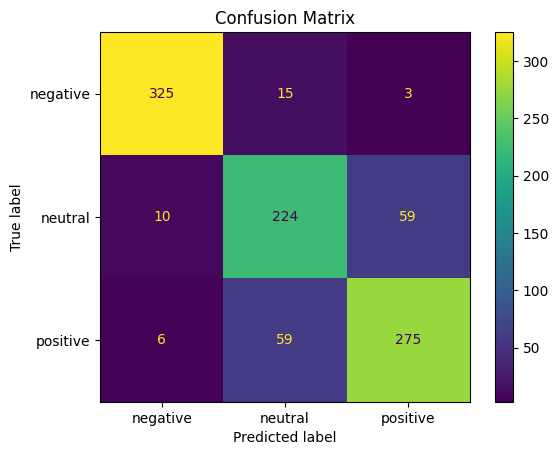

In [143]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

#### negative: 10 + 6 = 16 câu sai
#### neutral: 15 + 59 = 74 câu sai
#### positive: 3 + 59 = 62 câu sai

Lớp neutral bị nhầm nhiều nhất, với 74 câu.

Loi nham neutral voi possitive la do model chua phan biet ro duoc ranh gioi giua possitive va neutral do bi de nham lan giua cac tu nhu "on", "binh thuong" nhung tu co tinh chat neutral nhung cung xuat hien trong cac cau positive nhieu
Loi nham negative voi positive la 1 loi nghiem trong vi model da du doan hoan toan sai va dao nguoc ban tinh chat sentiment cua data



In [144]:
print(classification_report(
    y_test,
    best_pred,
    labels=best_model.classes_,
    digits=4
))

              precision    recall  f1-score   support

    negative     0.9531    0.9475    0.9503       343
     neutral     0.7517    0.7645    0.7580       293
    positive     0.8160    0.8088    0.8124       340

    accuracy                         0.8443       976
   macro avg     0.8403    0.8403    0.8402       976
weighted avg     0.8449    0.8443    0.8445       976



Lop yeu nhat la neutral
- cach truc tiep la bo sung them data ve cac cau neutral de model duoc train them du lieu de nhan dang duoc chinh xac hon

# 21. Accuracy, Precision, Recall, F1

In [145]:
print(classification_report(y_test, best_pred, zero_division=0))
p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       343
     neutral       0.75      0.76      0.76       293
    positive       0.82      0.81      0.81       340

    accuracy                           0.84       976
   macro avg       0.84      0.84      0.84       976
weighted avg       0.84      0.84      0.84       976

Macro F1   : 0.8402
Micro F1   : 0.8443
Weighted F1: 0.8445


## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

In [155]:
# 900 negative, 80 positive, 20 neutral
y_test_fake = (
    ["negative"] * 900 +
    ["positive"] * 80 +
    ["neutral"] * 20
)
#Model dự đoán:
# 880/900 negative đúng
#chỉ dự đoán đúng 40/80 positive
#chỉ dự đoán đúng 5/20 neutral
best_pred_fake = (
    ["negative"] * 880 +
    ["positive"] * 40 +
    ["neutral"] * 0 +
    # 40 positive bị nhầm thành negative
    ["negative"] * 40 +
    # 5 neutral đúng
    ["neutral"] * 5 +
    # 15 neutral bị nhầm thành negative
    ["negative"] * 15 +
    # 20 negative bị nhầm thành possitive
    ["negative"] * 20
)
accuracy = accuracy_score(
    y_test_fake,
    best_pred_fake
)
print("Accuracy:", round(accuracy, 4))

print("classification report")
print(classification_report(y_test_fake,best_pred_fake,zero_division=0,digits=4))
#accuracy van cao vi no tinh tren tong so, nen vi the neutral du doan kem
# nhung vi no chi la lop thieu so

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test_fake,
    best_pred_fake,
    average="macro",
    zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test_fake,
    best_pred_fake,
    average="micro",
    zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test_fake,
    best_pred_fake,
    average="weighted",
    zero_division=0
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))



Accuracy: 0.9
classification report
              precision    recall  f1-score   support

    negative     0.9215    0.9778    0.9488       900
     neutral     0.0000    0.0000    0.0000        20
    positive     0.5000    0.2500    0.3333        80

    accuracy                         0.9000      1000
   macro avg     0.4738    0.4093    0.4274      1000
weighted avg     0.8693    0.9000    0.8806      1000

Accuracy   : 0.9
Macro F1   : 0.4274
Micro F1   : 0.9
Weighted F1: 0.8806


Trong dữ liệu sentiment giáo dục mất cân bằng macro F1 có thể quan trọng hơn accuracy vì macro f1 đánh giá từng lớp với trọng số ngang nhau. 
accuracy thi có thể vẫn cao khi model dự đoán lớp chiếm đa số, trong khi các lớp thiểu số rất thấp. 
Nếu mục tiêu là nhận diện đầy đủ positive, neutral và negative feedback thi macro f1 cho cái nhìn chinh xac hon ve model va ket qua

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

ROC-AUC: 1.0


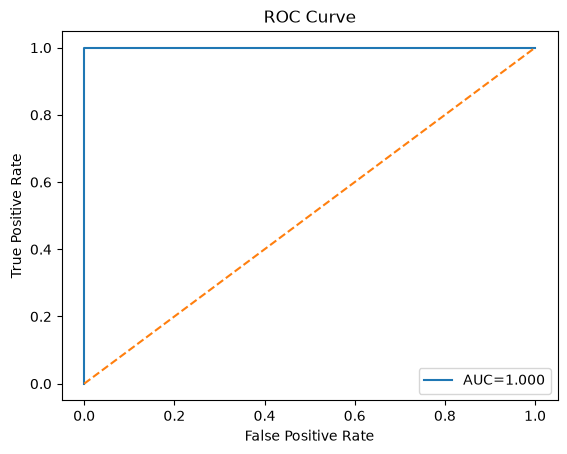

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

In [ ]:
# TODO: viết hàm evaluate_threshold(...)

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [ ]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

sentiment
positive    40
negative    10
neutral      8
Name: count, dtype: int64


## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

In [ ]:
def random_oversample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

def random_undersample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

# 24. Error Analysis theo chiều dài văn bản

In [ ]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

,text,gold,pred,n_words,correct,length_group
0,"Môi trường học tập ô nhiễm, không có không khí...",negative,negative,12,True,medium
1,"Quạt điều hòa khá ồn, gây khó chịu khi học tập.",negative,negative,11,True,medium
2,Bạn của tôi rất sáng suốt và có óc quan sát tốt.,positive,positive,12,True,medium
3,Tôi học được nhiều điều thú vị và tinh hoa tro...,positive,positive,14,True,long
4,Cô ấy hay làm việc sai sót và không bao giờ tự...,negative,negative,17,True,long


length_group
long      0.833559
medium    0.871901
short     0.918919
Name: correct, dtype: float64


## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [ ]:
mistakes = error_df[~error_df["correct"]].copy()
display(mistakes.head(20))

# TODO: thêm cột "error_category", "analysis", "proposed_fix"

,text,gold,pred,n_words,correct,length_group
10,Khu vực sống động của trường rất thú vị cho si...,neutral,positive,12,False,medium
14,Thầy đã giúp tôi có được nhiều kiến thức quan ...,neutral,positive,19,False,long
20,Cậu ấy có tầm nhìn xa và luôn đưa ra các chiến...,positive,neutral,26,False,long
21,Tôi cảm thấy giảng viên của mình không thực sự...,neutral,negative,20,False,long
22,Các buổi học được tổ chức chặt chẽ và có sự ch...,positive,neutral,15,False,long
23,"Giảng viên rất dễ tiếp cận và thân thiện, dễ t...",neutral,positive,18,False,long
32,"Cơ sở vật chất của trường khá đầy đủ, tuy nhiê...",neutral,negative,15,False,long
50,Cách đánh giá và phương pháp giảng dạy của trư...,positive,neutral,20,False,long
54,Thầy luôn đưa ra các gợi ý để sinh viên có thể...,neutral,positive,20,False,long
59,Một số bạn khá giỏi nhưng lúc làm việc chậm nh...,negative,neutral,12,False,medium


# 25. Bảng benchmark các baseline

In [ ]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

,model,accuracy,macro_f1,train_seconds,interpretability
3,TFIDF + LinearSVM,0.846758,0.845548,0.232876,medium
2,TFIDF + Logistic,0.840864,0.839867,0.662825,medium-high
5,Random Forest,0.823183,0.821551,3.193802,medium
1,TFIDF + NB,0.812377,0.808114,0.178135,medium-high
4,Decision Tree,0.722004,0.725039,0.146700,medium
0,Rule-based,0.576621,0.574196,0.000000,high


## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [ ]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    # Ví dụ scaffold — sinh viên hoàn thiện
    #
    # from transformers import (
    #     AutoTokenizer,
    #     AutoModelForSequenceClassification,
    #     TrainingArguments,
    #     Trainer
    # )
    #
    # MODEL_NAME = "vinai/phobert-base"
    # tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    #
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODEL_NAME,
    #     num_labels=3
    # )
    #
    # TODO:
    # 1. encode dataset
    # 2. map label -> id
    # 3. build Trainer
    # 4. fine-tune
    # 5. evaluate trên đúng test split
    #
    print("Transformer section enabled.")
else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.


## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble